# Dynamic vs Static Optimization Experiment

이 노트북은 15분 간격, 48시간(192 step) 합성 데이터셋을 만들고 아래 3가지 운전전략을 비교합니다.

- `dynamic_reoptimized`: 15분마다 현재 조건으로 재최적화
- `static_first_step`: 첫 시점 조건으로 한 번 최적화한 값을 끝까지 유지
- `static_average_condition`: 전체 평균 조건으로 한 번 최적화한 값을 끝까지 유지

주의:
- 현재 surrogate 모델 학습 범위에 맞추기 위해 `co2_concentration`은 0.16~0.24, `capture_target`은 0.68~0.75 범위에서 생성합니다.
- 원래 제안한 8~14% CO2 농도, 90% 포집목표는 현재 surrogate 학습 범위를 벗어나므로 그대로 쓰지 않았습니다.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd().resolve()
candidate_module_dirs = [
    cwd,
    cwd / 'mof' / 'optimization',
    cwd.parent / 'optimization',
]
module_dir = next((path for path in candidate_module_dirs if (path / 'experiment_helpers.py').exists()), None)
if module_dir is None:
    raise FileNotFoundError('experiment_helpers.py를 찾을 수 없습니다.')

if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))

from experiment_helpers import (
    build_summary_table,
    generate_all_scenarios,
    initialize_optimizer,
    run_all_scenarios_experiment,
    run_single_scenario_experiment,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)


c:\Users\junhyun111\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\junhyun111\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\junhyun111\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorfl

In [2]:
optimizer, paths, base_cost, base_constants = initialize_optimizer(module_dir)

print(f'train_csv: {paths["train_csv"]}')
print(f'purity target:   {base_cost.purity_target:.3f}')
print(f'recovery target: {base_cost.recovery_target:.3f}')
print(f'optimizer train shape: {optimizer.train_df.shape}')


train_csv: C:\Users\junhyun111\Desktop\psa\mof\dataset\data.csv
purity target:   0.404
recovery target: 0.723
optimizer train shape: (900, 35)


In [3]:
scenarios = generate_all_scenarios(start='2026-01-01 00:00', hours=48, freq='15min', seed=42)
print({name: df.shape for name, df in scenarios.items()})

ACTIVE_SCENARIO = 'price_volatile'
scenario_df = scenarios[ACTIVE_SCENARIO].copy()
scenario_df.head()


{'normal': (192, 14), 'price_volatile': (192, 14), 'load_volatile': (192, 14)}


,timestamp,scenario,co2_flow_rate,co2_concentration,electricity_price,heat_price,ambient_temp,capture_target,max_capacity,co2_mol_frac,h2o_ppmv,sox_ppmv,nox_ppmv,dust_mg_Nm3
0,2026-01-01 00:00:00,price_volatile,1000.000000,0.200000,85.000000,42.681639,22.000000,0.720000,7.000000,0.200000,52.006263,0.520898,5.100000,0.054090
1,2026-01-01 00:15:00,price_volatile,1031.204650,0.202635,80.000000,44.591313,22.195592,0.720473,7.044406,0.202635,52.885972,0.543795,5.171983,0.055675
2,2026-01-01 00:30:00,price_volatile,1010.982256,0.202240,88.000000,42.673883,22.783432,0.720247,7.013146,0.202240,56.893278,0.545324,5.230009,0.055879
3,2026-01-01 00:45:00,price_volatile,996.535475,0.203789,82.312220,45.036050,23.031607,0.724153,6.980797,0.203789,56.071003,0.540898,5.099007,0.055686
4,2026-01-01 01:00:00,price_volatile,1003.611478,0.203703,90.543442,44.152454,23.271861,0.716250,6.991356,0.203703,60.571003,0.552077,5.113611,0.053736


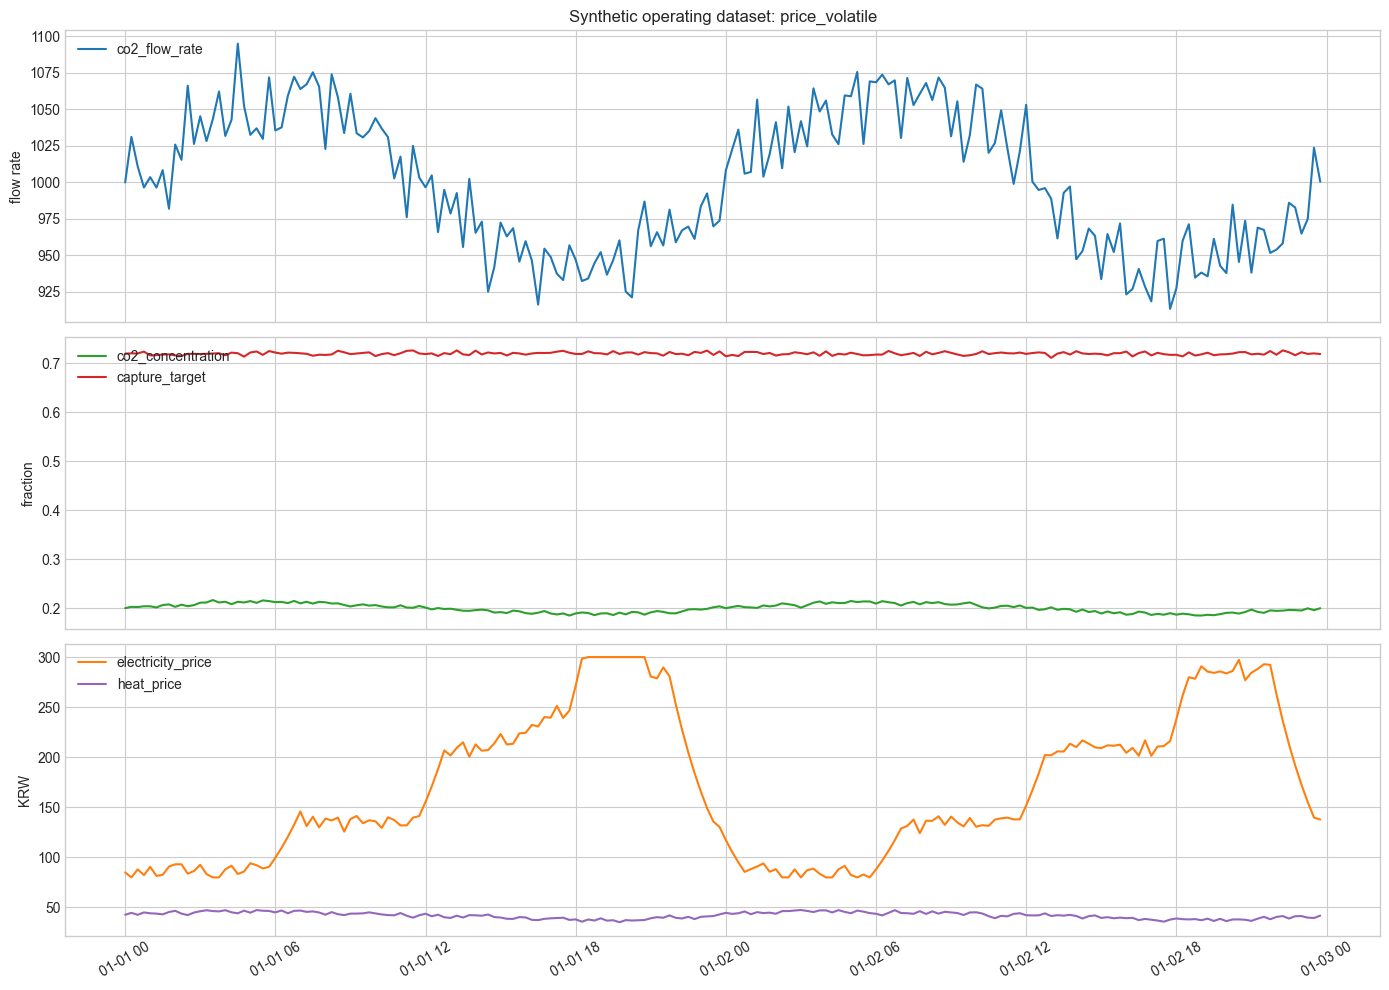

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(scenario_df['timestamp'], scenario_df['co2_flow_rate'], label='co2_flow_rate', color='tab:blue')
axes[0].set_ylabel('flow rate')
axes[0].legend(loc='upper left')

axes[1].plot(scenario_df['timestamp'], scenario_df['co2_concentration'], label='co2_concentration', color='tab:green')
axes[1].plot(scenario_df['timestamp'], scenario_df['capture_target'], label='capture_target', color='tab:red')
axes[1].set_ylabel('fraction')
axes[1].legend(loc='upper left')

axes[2].plot(scenario_df['timestamp'], scenario_df['electricity_price'], label='electricity_price', color='tab:orange')
axes[2].plot(scenario_df['timestamp'], scenario_df['heat_price'], label='heat_price', color='tab:purple')
axes[2].set_ylabel('KRW')
axes[2].legend(loc='upper left')

axes[0].set_title(f'Synthetic operating dataset: {ACTIVE_SCENARIO}')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## Single Scenario Run

기본값은 `ACTIVE_SCENARIO` 하나만 실행합니다. 15분마다 재최적화를 수행하므로 시간이 꽤 걸릴 수 있습니다.

권장 시작값:
- 빠른 테스트: `n_samples=80`, `local_steps=1`, `elite_size=4`
- 본 실험: `n_samples=150~250`, `local_steps=2`, `elite_size=6`


In [5]:
n_samples = 120
local_steps = 1
elite_size = 4
seed = 42

results_df = run_single_scenario_experiment(
    optimizer=optimizer,
    scenario_df=scenario_df,
    base_cost=base_cost,
    base_constants=base_constants,
    n_samples=n_samples,
    local_steps=local_steps,
    elite_size=elite_size,
    seed=seed,
)

summary_df = build_summary_table(results_df)
summary_df


,scenario,strategy,avg_cost_per_tco2,final_cumulative_cost_per_tco2,total_captured_tons,total_cost
0,price_volatile,dynamic_reoptimized,134776.900145,131992.625399,303.874729,4.010922e+07
1,price_volatile,static_average_condition,136651.593589,133745.914622,303.874729,4.064200e+07
2,price_volatile,static_first_step,141054.938708,137960.699680,303.874729,4.192277e+07


In [6]:
decision_cols = ['strategy', 'tADS', 'PL', 'v0', 't_press', 't_depress']
first_decisions = results_df.groupby('strategy', as_index=False).first()[decision_cols]
first_decisions


,strategy,tADS,PL,v0,t_press,t_depress
0,dynamic_reoptimized,171.148281,0.334889,0.029818,38.481232,51.040998
1,static_average_condition,163.212393,0.292016,0.030344,57.627076,33.296611
2,static_first_step,163.115707,0.274999,0.029999,45.861265,35.309691


In [7]:
results_output_path = module_dir / f'experiment_results_{ACTIVE_SCENARIO}.csv'
summary_output_path = module_dir / f'experiment_summary_{ACTIVE_SCENARIO}.csv'

results_df.to_csv(results_output_path, index=False)
summary_df.to_csv(summary_output_path, index=False)

print(results_output_path)
print(summary_output_path)


C:\Users\junhyun111\Desktop\psa\mof\optimization\experiment_results_price_volatile.csv
C:\Users\junhyun111\Desktop\psa\mof\optimization\experiment_summary_price_volatile.csv


## Cost Plots

아래 그래프 2개는 요청하신 핵심 결과입니다.
- 각 시간별 톤당 비용
- 누적 톤당 비용


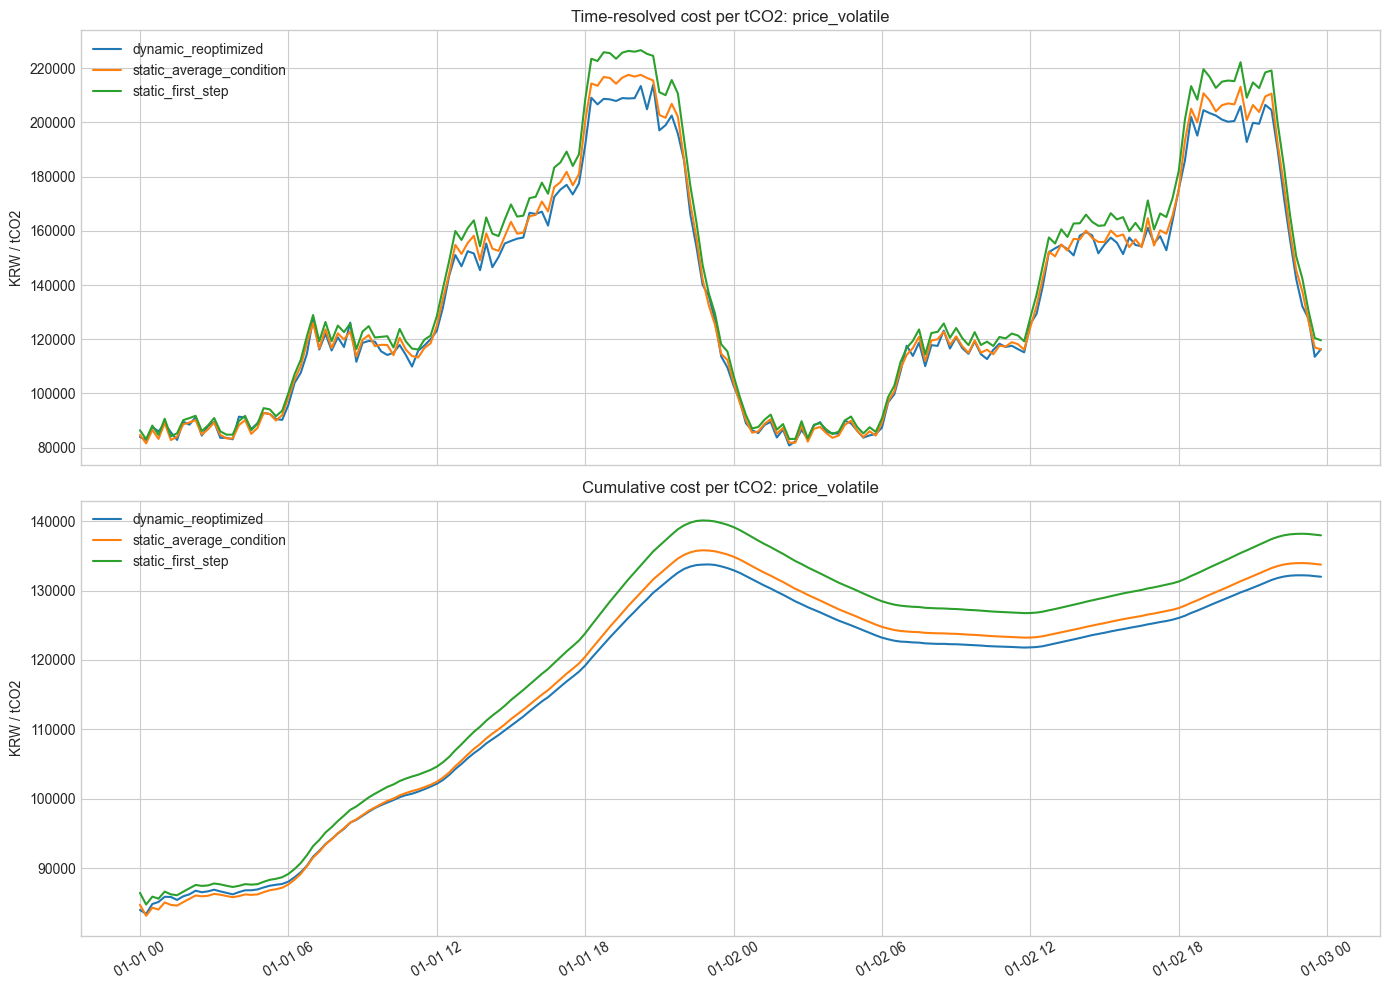

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for strategy, group in results_df.groupby('strategy'):
    axes[0].plot(group['timestamp'], group['adjusted_total_cost_per_tco2'], label=strategy)
    axes[1].plot(group['timestamp'], group['cumulative_cost_per_tco2'], label=strategy)

axes[0].set_title(f'Time-resolved cost per tCO2: {ACTIVE_SCENARIO}')
axes[0].set_ylabel('KRW / tCO2')
axes[0].legend(loc='upper left')

axes[1].set_title(f'Cumulative cost per tCO2: {ACTIVE_SCENARIO}')
axes[1].set_ylabel('KRW / tCO2')
axes[1].legend(loc='upper left')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


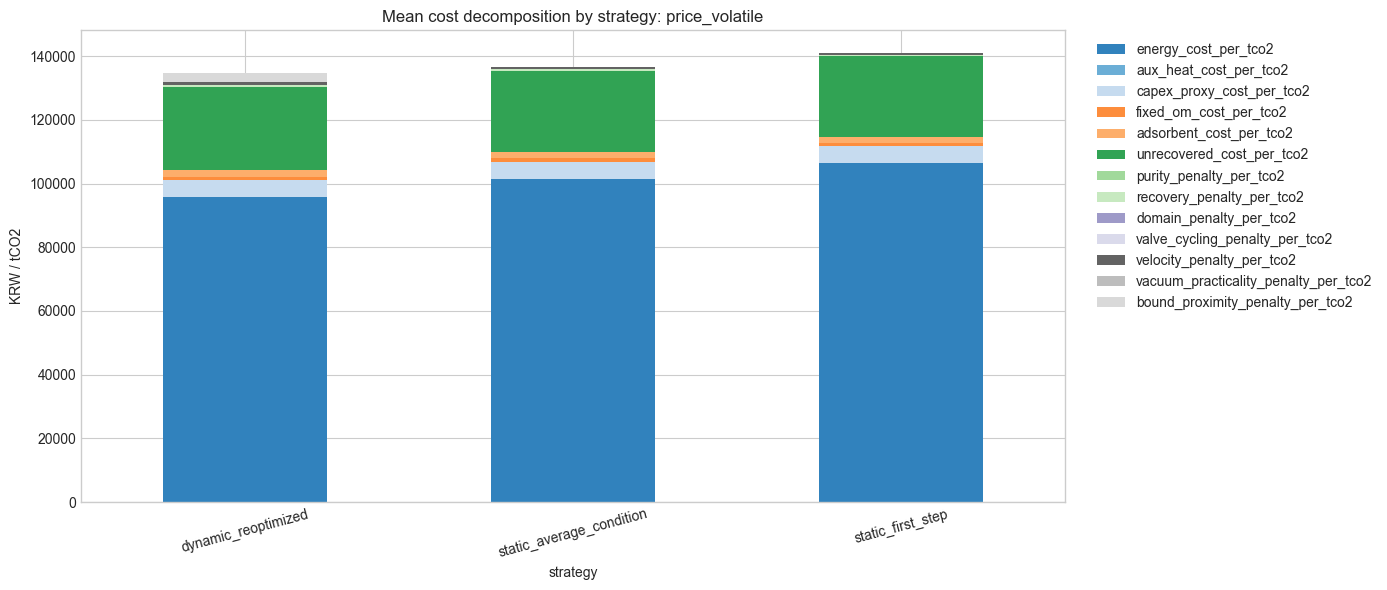

In [9]:
cost_breakdown_cols = [
    'energy_cost_per_tco2',
    'aux_heat_cost_per_tco2',
    'capex_proxy_cost_per_tco2',
    'fixed_om_cost_per_tco2',
    'adsorbent_cost_per_tco2',
    'unrecovered_cost_per_tco2',
    'purity_penalty_per_tco2',
    'recovery_penalty_per_tco2',
    'domain_penalty_per_tco2',
    'valve_cycling_penalty_per_tco2',
    'velocity_penalty_per_tco2',
    'vacuum_practicality_penalty_per_tco2',
    'bound_proximity_penalty_per_tco2',
]

mean_breakdown = results_df.groupby('strategy')[cost_breakdown_cols].mean()
ax = mean_breakdown.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='tab20c')
ax.set_title(f'Mean cost decomposition by strategy: {ACTIVE_SCENARIO}')
ax.set_ylabel('KRW / tCO2')
plt.xticks(rotation=15)
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()


## Optional: Run All Scenarios

아래 셀은 `normal`, `price_volatile`, `load_volatile` 3개 시나리오를 모두 돌립니다. 시간이 더 오래 걸립니다.


In [10]:
RUN_ALL_SCENARIOS = False

if RUN_ALL_SCENARIOS:
    all_results_df = run_all_scenarios_experiment(
        optimizer=optimizer,
        scenarios=scenarios,
        base_cost=base_cost,
        base_constants=base_constants,
        n_samples=n_samples,
        local_steps=local_steps,
        elite_size=elite_size,
        seed=seed,
    )
    all_summary_df = build_summary_table(all_results_df)
    display(all_summary_df)
else:
    print('RUN_ALL_SCENARIOS=False 이므로 실행하지 않습니다.')


RUN_ALL_SCENARIOS=False 이므로 실행하지 않습니다.


In [11]:
if RUN_ALL_SCENARIOS:
    pivot_df = all_summary_df.pivot(index='scenario', columns='strategy', values='final_cumulative_cost_per_tco2')
    ax = pivot_df.plot(kind='bar', figsize=(12, 6))
    ax.set_title('Final cumulative cost per tCO2 by scenario and strategy')
    ax.set_ylabel('KRW / tCO2')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()
